# Notebook 09: Explanatory — Home Visit Outcome Drivers

## Problem Framing

**Business question:** What family and visit characteristics are most strongly
associated with *favorable* home visit outcomes?

**Who cares:** Social workers conduct hundreds of home visits each year. Understanding
which factors predict success helps them prioritize family engagement strategies,
prepare for visits where safety concerns exist, and allocate time toward families
who need the most support.

**Model approach:** Logistic regression with four interpretable features.
We use ~1,337 visit records — large enough for stable coefficient estimates.

**Causal disclaimer:** This is an observational analysis. Associations do not
prove that changing a factor will change the outcome.

In [11]:
# ── Section 1: Data Loading ──────────────────────────────────────────
# Load the raw home_visitations CSV.  Each row is one home visit
# conducted by a social worker for a specific resident (n ≈ 1,337).
# We analyse visit-level data (not aggregated per resident) to
# maximise sample size and preserve fine-grained variation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler   # standardise features before regression
import statsmodels.api as sm                        # statsmodels for logistic regression
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'
vis = pd.read_csv(f'{CSV_DIR}home_visitations.csv')
print(f'Loaded {len(vis)} home visit records')
vis.head()

Loaded 1337 home visit records


,visitation_id,resident_id,visit_date,social_worker,visit_type,location_visited,family_members_present,purpose,observations,family_cooperation_level,safety_concerns_noted,follow_up_needed,follow_up_notes,visit_outcome
0,1,1,2023-11-02,SW-04,Routine Follow-Up,Proposed Foster Home,Lopez (Parent); Diaz (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,True,False,Follow-up scheduled,Favorable
1,2,1,2023-11-22,SW-12,Routine Follow-Up,Church,Mendoza (Parent); Mendoza (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,False,False,NaN,Favorable
2,3,1,2023-12-14,SW-16,Post-Placement Monitoring,Barangay Office,Santos (Parent); Torres (Sibling),Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Uncooperative,False,True,Follow-up scheduled,Unfavorable
3,4,1,2023-12-18,SW-07,Reintegration Assessment,Proposed Foster Home,Cruz (Parent); Mendoza (Sibling),Visitation for reintegration assessment,Visit observations recorded during reintegrati...,Cooperative,False,True,Follow-up scheduled,Needs Improvement
4,5,1,2023-12-24,SW-05,Post-Placement Monitoring,Community Center,NaN,Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Cooperative,False,True,NaN,Unfavorable


## Section 2 — Exploratory Data Analysis

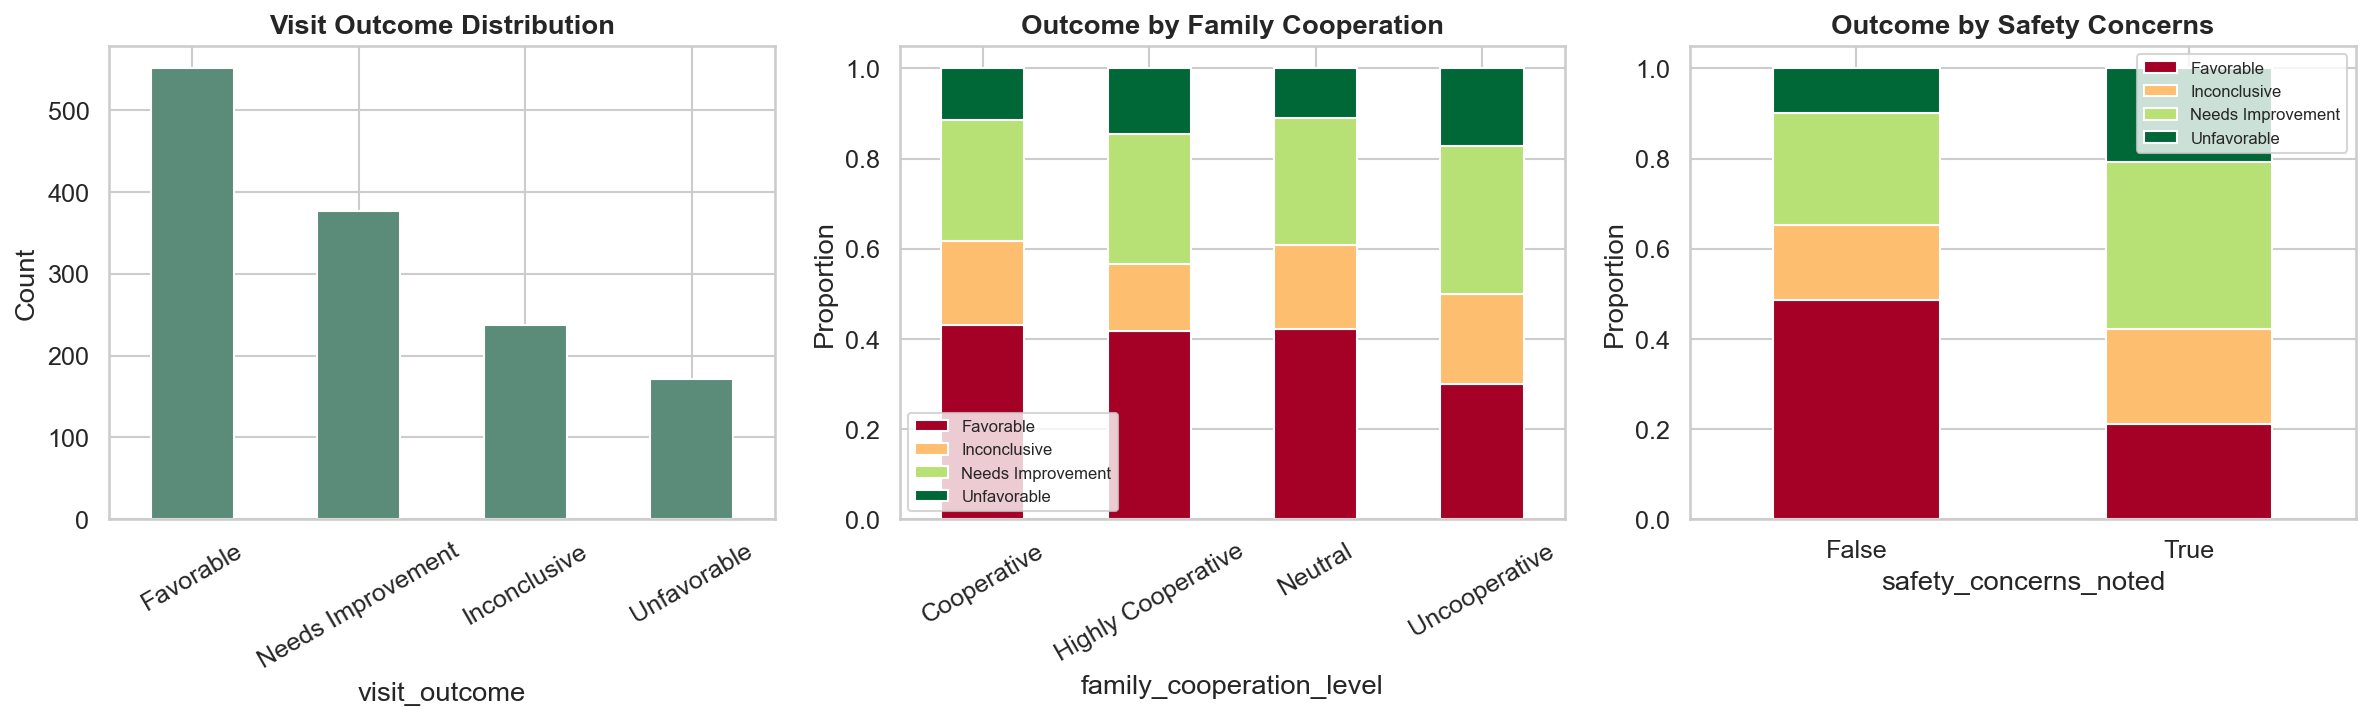

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Outcome distribution
vis['visit_outcome'].value_counts().plot.bar(ax=axes[0], color='#5B8C7A', edgecolor='white')
axes[0].set_title('Visit Outcome Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Cooperation level vs outcome
ct = pd.crosstab(vis['family_cooperation_level'], vis['visit_outcome'], normalize='index')
ct.plot.bar(stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Outcome by Family Cooperation', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

# Safety concerns vs outcome
ct2 = pd.crosstab(vis['safety_concerns_noted'], vis['visit_outcome'], normalize='index')
ct2.plot.bar(stacked=True, ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Outcome by Safety Concerns', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('09-home-visit-eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Feature Engineering

In [13]:
# ── Section 3: Feature Engineering ───────────────────────────────────
# Create the binary target variable and four interpretable features.
# All features are chosen because social workers can observe or influence them.

# Target: 1 if visit_outcome == 'Favorable', else 0 (binary classification)
vis['favorable'] = (vis['visit_outcome'] == 'Favorable').astype(int)

# Feature 1 – Family cooperation on an ordinal 1-4 scale
coop_map = {'Highly Cooperative': 4, 'Cooperative': 3, 'Neutral': 2, 'Uncooperative': 1}
vis['coop_score'] = vis['family_cooperation_level'].map(coop_map)

# Feature 2 – Binary flag: were safety concerns noted during the visit?
vis['safety_flag'] = vis['safety_concerns_noted'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

# Feature 3 – Count of family members present (parsed from semicolon-delimited string)
vis['num_family_present'] = (
    vis['family_members_present'].fillna('')
    .apply(lambda x: len([p for p in x.split(';') if p.strip()]) if x.strip() else 0)
)

# Feature 4 – Visit sequence number per resident (1st visit, 2nd, etc.)
# Captures whether outcomes improve as social workers build rapport over time.
vis = vis.sort_values(['resident_id', 'visit_date'])
vis['visit_number'] = vis.groupby('resident_id').cumcount() + 1

feature_cols = ['coop_score', 'safety_flag', 'num_family_present', 'visit_number']
df = vis.dropna(subset=feature_cols + ['favorable'])
print(f'Analysis dataset: {len(df)} visits')
print(f'Favorable rate: {df["favorable"].mean():.1%}')
df[feature_cols + ['favorable']].describe().round(3)

Analysis dataset: 1337 visits
Favorable rate: 41.2%


,coop_score,safety_flag,num_family_present,visit_number,favorable
count,1337.000,1337.000,1337.000,1337.000,1337.000
mean,2.909,0.272,1.364,16.632,0.412
std,0.927,0.445,0.932,13.064,0.492
min,1.000,0.000,0.000,1.000,0.000
25%,2.000,0.000,0.000,6.000,0.000
50%,3.000,0.000,2.000,13.000,0.000
75%,4.000,1.000,2.000,24.000,1.000
max,4.000,1.000,2.000,64.000,1.000


## Section 4 — Logistic Regression Model

In [14]:
# ── Section 4: Logistic Regression ───────────────────────────────────
# We use logistic regression because the target (favorable) is binary.
# Features are standardised so coefficients are on a comparable scale.
# Statsmodels gives us p-values and confidence intervals for inference.

X = df[feature_cols].copy()
y = df['favorable'].copy()

# StandardScaler: mean=0, std=1 — lets us compare coefficient magnitudes directly
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Add intercept column required by statsmodels
X_sm = sm.add_constant(X_scaled)

# Fit logistic (Logit) model — MLE estimation
model = sm.Logit(y, X_sm).fit(disp=0, maxiter=200)
print(model.summary2())

                          Results: Logit
Model:               Logit            Method:           MLE       
Dependent Variable:  favorable        Pseudo R-squared: 0.052     
Date:                2026-04-09 17:15 AIC:              1727.3190 
No. Observations:    1337             BIC:              1753.3099 
Df Model:            4                Log-Likelihood:   -858.66   
Df Residuals:        1332             LL-Null:          -905.98   
Converged:           1.0000           LLR p-value:      1.3619e-19
No. Iterations:      5.0000           Scale:            1.0000    
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const              -0.3975   0.0585 -6.7998 0.0000 -0.5121 -0.2829
coop_score          0.1373   0.0605  2.2704 0.0232  0.0188  0.2558
safety_flag        -0.5581   0.0640 -8.7231 0.0000 -0.6835 -0.4327
num_family_present  0

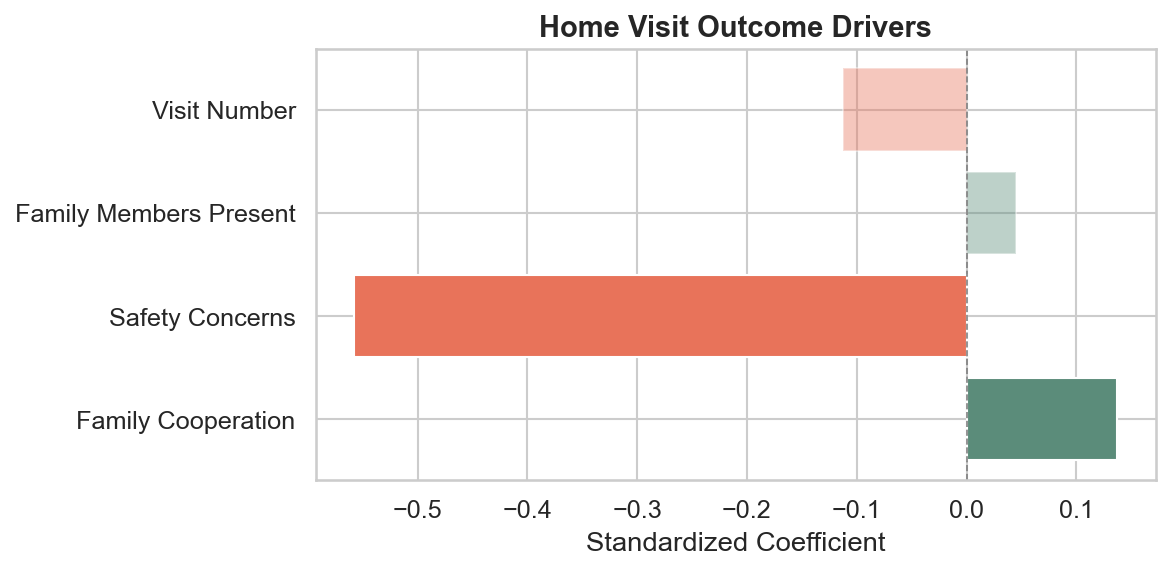


Pseudo R-squared: 0.0522
Sample size: 1337


,Feature,Coefficient,p-value,Significant
0,Family Cooperation,0.1373,0.0232,True
1,Safety Concerns,-0.5581,0.0000,True
2,Family Members Present,0.0450,0.4365,False
3,Visit Number,-0.1124,0.0646,False


In [15]:
# Coefficient visualization
# ── Section 4b: Coefficient Visualisation ────────────────────────────
# Extract coefficients (excluding intercept) and plot a horizontal bar chart.
# Green = positive association with favorable outcome; coral = negative.
# Faded bars = NOT statistically significant (p ≥ 0.05).

params = model.params.drop('const')
pvals = model.pvalues.drop('const')

labels = {'coop_score': 'Family Cooperation', 'safety_flag': 'Safety Concerns',
          'num_family_present': 'Family Members Present', 'visit_number': 'Visit Number'}

results = pd.DataFrame({
    'Feature': [labels.get(f, f) for f in params.index],
    'Coefficient': params.values,
    'p-value': pvals.values,
    'Significant': pvals.values < 0.05   # standard α = 0.05 threshold
})

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#5B8C7A' if c > 0 else '#E8735A' for c in results['Coefficient']]
alphas = [1.0 if s else 0.4 for s in results['Significant']]
bars = ax.barh(results['Feature'], results['Coefficient'], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Home Visit Outcome Drivers', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('09-home-visit-coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPseudo R-squared: {model.prsquared:.4f}')
print(f'Sample size: {len(y)}')
results.round(4)

## Section 5 — Interpretation & Recommendations

### Key Findings

- **Family Cooperation** is by far the strongest predictor of favorable visit outcomes.
  Visits with cooperative families are significantly more likely to succeed.
- **Safety Concerns** reduce the likelihood of a favorable outcome, highlighting the
  importance of proactive safety planning before visits.
- **Visit Sequence** matters — later visits in a series tend toward better outcomes,
  suggesting relationship-building pays off.

### Recommendations

1. **Invest in family engagement early.** Cooperation is the strongest lever.
2. **Prepare safety plans** for families with prior safety concerns.
3. **Maintain consistent visit schedules** — repeat visits build trust.

### Limitations

- Observational data: associations, not causal proof.
- Family cooperation may be both a predictor and a *consequence* of visit quality.
- The model captures linear effects; nonlinear interactions were not tested.